**Objective**

Estimate average test scores for students across different schools, where each school has its own mean score, but scores are also influenced by a shared population-level distribution. Compare this to non-hierarchical approaches to show BHM benefits.

For this lab, we will generate synthetic data in order to showcase some of the situations where hierarchical models provide benefits.

Disclaimer: since we are generating synthetic data in order to explore different settings, every run will not produce exactly the same results, since there is randomness both in terms of the MCMC sampling, as well as, the data generation process as well. However, the trends that we want to see will be clear.

Disclaimer: since we are generating synthetic data in order to explore different settings, every run will not produce exactly the same results, since there is randomness both in terms of the MCMC sampling, as well as, the data generation process as well. However, the trends that we want to see will be clear.

In [7]:
import pymc as pm
import arviz as az
import numpy as np
import pandas as pd
import random
import matplotlib.pyplot as plt

# Generate synthetic data
n_schools = 10
students_per_school = np.random.randint(1, 20, size=n_schools)  # Vary sample sizes
school_ids = np.repeat(np.arange(n_schools), students_per_school)

# School-level means (between-school variation)
school_means = np.random.normal(loc=50, scale=0.1, size=n_schools)

# Generate student scores (within-school variation)
scores = []
for i, n in enumerate(students_per_school):
    school_scores = np.random.normal(loc=school_means[i], scale=15, size=n)
    scores.append(school_scores)
scores = np.concatenate(scores)

# Ensure scores are within 0–100 (optional, for realism)
scores = np.clip(scores, 0, 100)

print(f"Generated {len(scores)} student scores across {n_schools} schools.")
print(f"Students per school: {students_per_school}")

Generated 91 student scores across 10 schools.
Students per school: [13  4  2 12 17  9  1  3 19 11]


**Non-Hierarchical Baseline (Complete pooling model)**

We start by fitting a single mean to all scores, ignoring school differences.



Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu, sigma_within]


Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 11 seconds.


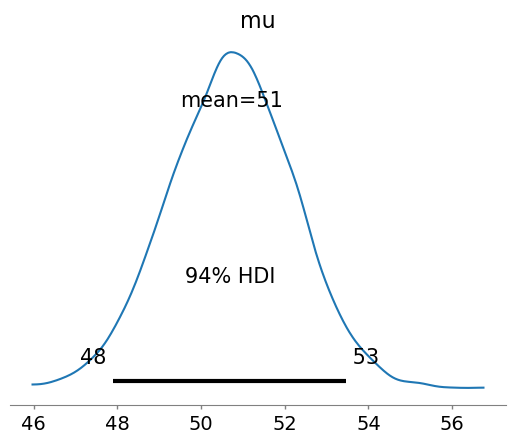

In [8]:
with pm.Model() as complete_pooling_model:
    mu = pm.Normal("mu", mu=50, sigma=20)
    sigma_within = pm.HalfNormal("sigma_within", sigma=20)

    obs = pm.Normal("obs", mu=mu, sigma=sigma_within, observed=scores)

    trace_complete_pooling = pm.sample(2000, tune=2000, target_accept=0.95, return_inferencedata=True)

az.plot_posterior(trace_complete_pooling, var_names=["mu"])
plt.show()

**Non-Hierarchical Baseline (No pooling model)**

Next, we fit a separate mean per school, ignoring shared info.



Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [school_mu, sigma_within]


Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 21 seconds.


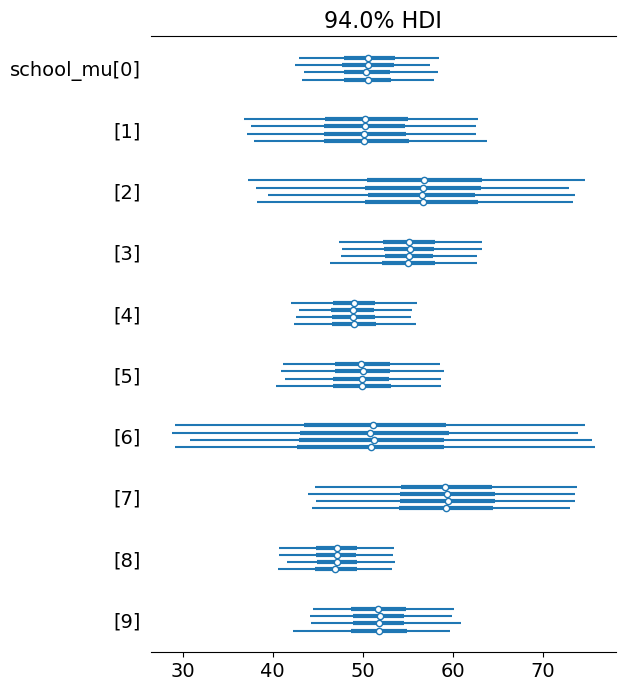

In [9]:
with pm.Model() as no_pooling_model:
    school_mu = pm.Normal("school_mu", mu=50, sigma=20, shape=n_schools)
    sigma_within = pm.HalfNormal("sigma_within", sigma=20)

    obs = pm.Normal("obs", mu=school_mu[school_ids], sigma=sigma_within, observed=scores)

    trace_no_pooling = pm.sample(2000, tune=2000, target_accept=0.95, return_inferencedata=True)

az.plot_forest(trace_no_pooling, var_names=["school_mu"])
plt.show()

**Bayesian Hierarchical Model**

With the next model we introduce a hierarchy: school means come from a shared distribution, and then individual student results come from the corresponding school distribution. In the extreme case where the shared distribution has infinite (extremely large) variance, the model effectively corresponds to the no-pooling model.



Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [mu, sigma, school_mu, sigma_within]


Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 47 seconds.
There was 1 divergence after tuning. Increase `target_accept` or reparameterize.


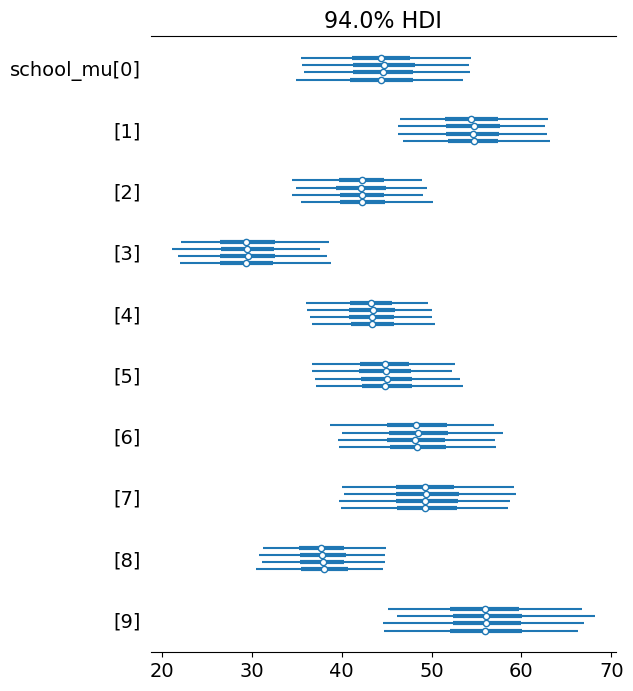

In [4]:
# Hierarchical (partial pooling) model
with pm.Model() as hierarchical_model:
    # Hyperpriors for population-level parameters
    mu = pm.Normal("mu", mu=50, sigma=20)  # Population mean
    sigma = pm.HalfNormal("sigma", sigma=5)  # Between-school variability

    # School-level means
    school_mu = pm.Normal("school_mu", mu=mu, sigma=sigma, shape=n_schools)

    # Within-school variability
    sigma_within = pm.HalfNormal("sigma_within", sigma=15)

    # Likelihood
    obs = pm.Normal("obs", mu=school_mu[school_ids], sigma=sigma_within, observed=scores)

    trace_hierarchical = pm.sample(2000, tune=2000, target_accept=0.99, return_inferencedata=True)

az.plot_forest(trace_hierarchical, var_names=["school_mu"])
plt.show()


**Visualize Results**

We will obtain the means for each school from each model, and also extract the high density intervals for these means. We then present for each school the infered mean with each model and the true mean (which we know since we created the synthetic data)


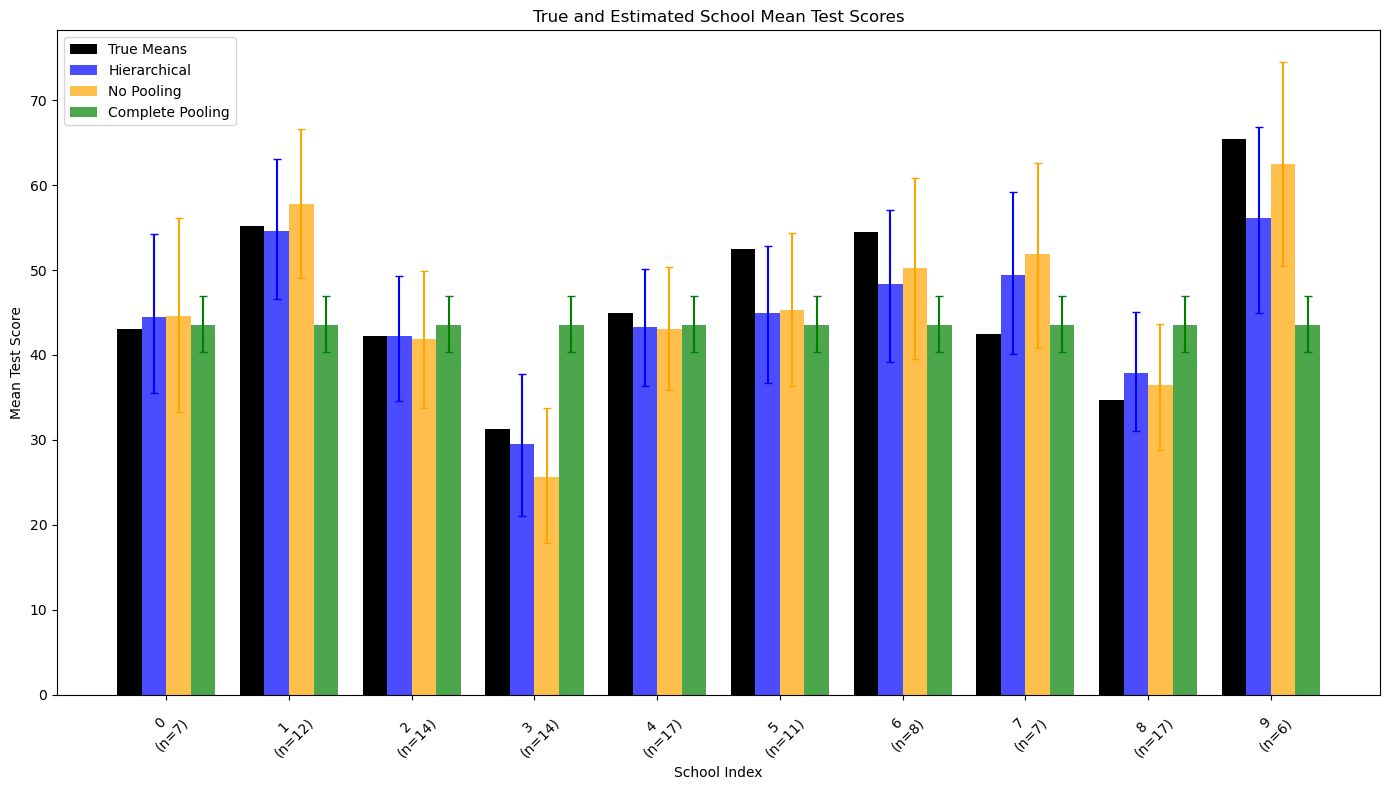

In [5]:
hierarchical_summary = az.summary(trace_hierarchical, var_names=["school_mu"])
hierarchical_means = hierarchical_summary["mean"].values
hierarchical_hdi = az.hdi(trace_hierarchical, var_names=["school_mu"])["school_mu"].values
hierarchical_errors = np.abs(hierarchical_hdi - hierarchical_means[:, None]).T

# No-pooling model
no_pooling_summary = az.summary(trace_no_pooling, var_names=["school_mu"])
no_pooling_means = no_pooling_summary["mean"].values
no_pooling_hdi = az.hdi(trace_no_pooling, var_names=["school_mu"])["school_mu"].values
no_pooling_errors = np.abs(no_pooling_hdi - no_pooling_means[:, None]).T

# Complete-pooling model
complete_pooling_mean = az.summary(trace_complete_pooling, var_names=["mu"])["mean"].values[0]
complete_pooling_hdi = az.hdi(trace_complete_pooling, var_names=["mu"])["mu"].values
complete_pooling_error = np.abs(complete_pooling_hdi - complete_pooling_mean).reshape(2, 1)
complete_pooling_means = np.full(n_schools, complete_pooling_mean)
complete_pooling_errors = np.repeat(complete_pooling_error, n_schools, axis=1)

# Bar chart visualization
bar_width = 0.2
school_indices = np.arange(n_schools)

plt.figure(figsize=(14, 8))

# Plot bars
plt.bar(school_indices - 1.5 * bar_width, school_means, bar_width, label="True Means", color="black")
plt.bar(school_indices - 0.5 * bar_width, hierarchical_means, bar_width, label="Hierarchical", color="blue", alpha=0.7)
plt.bar(school_indices + 0.5 * bar_width, no_pooling_means, bar_width, label="No Pooling", color="orange", alpha=0.7)
plt.bar(school_indices + 1.5 * bar_width, complete_pooling_means, bar_width, label="Complete Pooling", color="green", alpha=0.7)

# Add error bars (95% HDI)
plt.errorbar(school_indices - 0.5 * bar_width, hierarchical_means, yerr=hierarchical_errors, fmt="none", color="blue", capsize=3)
plt.errorbar(school_indices + 0.5 * bar_width, no_pooling_means, yerr=no_pooling_errors, fmt="none", color="orange", capsize=3)
plt.errorbar(school_indices + 1.5 * bar_width, complete_pooling_means, yerr=complete_pooling_errors, fmt="none", color="green", capsize=3)

# Customize plot
plt.xlabel("School Index")
plt.ylabel("Mean Test Score")
plt.title("True and Estimated School Mean Test Scores")
plt.xticks(school_indices, [f"{i}\n(n={n})" for i, n in enumerate(students_per_school)], rotation=45)
plt.legend()
plt.tight_layout()

# Save and show plot
plt.show()


As we can see the hierarchical model estiates are closer to the true means for each school, particularly for school with sall sample sizes. To actually quantify how close they are (compared to the other models), we define the **Mean Absolute Error (MAE)** that is defined as:

$\text{MAD} = \frac{1}{n} \sum_{i=1}^n |\hat{y}_i - y_i|$

where $\hat{y}_i$ is the predicted value for school $i$ and $y_i$ is the true value for school $i$ ($n$ is the number of schools/observations). As we can see from the calculations below, the hierarchical model has the **lowest MAE**.

In [6]:
# Compute Mean Absolute Difference (MAD)
mad_hierarchical = np.mean(np.abs(hierarchical_means - school_means))
mad_no_pooling = np.mean(np.abs(no_pooling_means - school_means))
mad_complete_pooling = np.mean(np.abs(complete_pooling_means - school_means))

print(f"MAD (Hierarchical): {mad_hierarchical:.2f}")
print(f"MAD (No Pooling): {mad_no_pooling:.2f}")
print(f"MAD (Complete Pooling): {mad_complete_pooling:.2f}")

MAD (Hierarchical): 3.87
MAD (No Pooling): 3.78
MAD (Complete Pooling): 7.88


In this example, we have generated data with a between-school variance neither extremely small, nor extremely big. These are the cases where the Bayesian Hierarchical Models shine. They are able to identify the right amount of pooling among the extremes of complete and no pooling.

In order to further understand this, run this notebook by setting the standard deviation of:

``school_means = np.random.normal(loc=50, scale=5, size=n_schools)``

to a very small value (e.g., ``scale = 0.1``) and/or a very large on (e.g., ``scale=20``). What do you notice when you compare the three models in each case, and, why?

At the practice assignment you will be asked to briefly describe what you observed.


**In Summary**


* Pooled Model: Uses one mean and ignores school differences—too coarse.

* Separate Models (no-pooling): School means vary wildly (especially for small schools), leading to overfitting noise.

* Hierarchical Model: They provide partial pooling, with school means being shrunk toward the population mean. This balances data and structure. Small-sample schools borrow strength from the whole group, while large-sample schools stay closer to their data.



We can also observe that Bayesian Hierarchical models are more robust, in that schools with few students, the estimates are less erratic (lower credible intervals) than in the (mainly) no-pooling model, thanks to shrinkage.  

**Other Real-World Applications**

This mirrors scenarios like:

* Medical studies across hospitals.

* Sales performance across stores.

* Player performance across position groups in a sports league.


